# 00 - Data Pipeline
### Phase 1: Labeled Dataset Construction via Automated Forced Alignment

This notebook implements all stages of Phase 1:
1. Download video audio and caption tracks.
2. Parse caption timestamps and build full transcript.
3. Apply Azerbaijani text normalization (Turkic case-folding).
4. Compute tokenizer vocabulary coverage diagnostics.
5. Run forced-alignment using MMS (`facebook/mms-1b-all`) and `ctc-segmentation`.
6. Derive optimal 5-10s segments at pause boundaries.
7. Perform zero-shot decodes using Whisper and MMS to calculate cross-model agreement.
8. Apply confidence and agreement decile filters.
9. Export stratified QA spot-check sheet (human-in-the-loop validation).
10. Partition dataset into stratified train/val/test splits.

### Stage 1: Mount Drive, Install Dependencies, & Load Configuration

In [1]:
# 1. Colab Google Drive Mount
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/VAD
except ImportError:
    print("Not running on Google Colab. Operating in local project folder.")

# 2. Install missing packages
try:
    import transformers
    import datasets
    import peft
    import mlflow
    import ctc_segmentation
    import jiwer
    import soundfile
    print("All key dependencies are already installed.")
except ImportError:
    print("Installing dependencies...")
    !pip uninstall -y -q torchao
    !pip install -q -r requirements.txt
    # Reinstall ctc-segmentation from source to ensure compatibility with active NumPy (which is typically NumPy 2.x in Colab)
    !pip install -q --no-binary ctc-segmentation ctc-segmentation

# 3. Add src/ to Python path
import sys
import os
sys.path.append('src')
print("System path updated. Working directory contents:", os.listdir('.'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/VAD
All key dependencies (including NumPy 1.x) are already installed.
System path updated. Working directory contents: ['documentation', 'configs', 'src', 'data', 'notebooks', 'runs', 'reports', 'requirements.txt']


In [2]:
# Load and print merged configurations
from config_loader import load_config

config = load_config(None)
print("Merged Configuration Parameters:")
for k, v in config.to_dict().items():
    print(f"  {k}: {v}")

Merged Configuration Parameters:
  project_root: /content/drive/MyDrive/VAD
  seed: 42
  sample_rate: 16000
  video_url: https://www.youtube.com/watch?v=LPre3ILXY1k
  segment_min_duration_sec: 3
  segment_target_duration_sec: [5, 10]
  segment_max_duration_sec: 12
  alignment_confidence_drop_percentile: 10
  cross_model_agreement_drop_percentile: 10
  qa_sample_size: 18
  qa_sample_strata: 3
  qa_problem_rate_retune_threshold: 0.25
  split_ratios: [0.8, 0.1, 0.1]


### Stage 2: Download Audio & Captions

In [3]:
from audio_io import download_resources
import os

raw_audio_path = "data/raw/audio.wav"
raw_caption_dir = "data/raw"

caption_files = [f for f in os.listdir(raw_caption_dir) if f.startswith("captions.") and f.endswith((".vtt", ".srt"))] if os.path.exists(raw_caption_dir) else []
if os.path.exists(raw_audio_path) and caption_files:
    print("Audio and captions already downloaded. Skipping download.")
else:
    download_resources(
        url=config.video_url,
        output_audio_path=raw_audio_path,
        output_caption_dir=raw_caption_dir
    )
    print("Resource download stage completed.")
print("Verifying output files:")
print("  - Audio exists:", os.path.exists(raw_audio_path))
print("  - Directory contents:", os.listdir(raw_caption_dir))

Audio and captions already downloaded. Skipping download.
Verifying output files:
  - Audio exists: True
  - Directory contents: ['audio.wav', 'captions.az.vtt']


### Stage 3: Parse Captions

In [4]:
from text_normalization import parse_subtitles

# Locate the downloaded caption file (could be .vtt or .srt)
caption_files = [f for f in os.listdir(raw_caption_dir) if f.startswith("captions.") and f.endswith((".vtt", ".srt"))]
if not caption_files:
    raise FileNotFoundError("No subtitle file downloaded. Check yt-dlp logs.")

caption_path = os.path.join(raw_caption_dir, caption_files[0])
raw_segments = parse_subtitles(caption_path)

print(f"Successfully parsed {len(raw_segments)} raw caption segments.")
print("First 3 segments:")
for start, end, text in raw_segments[:3]:
    print(f"  [{start:.2f}s -> {end:.2f}s]: {text}")

# Concatenate into full reference transcript string
# Preserve sentence boundaries with a single space
full_reference_transcript = " ".join([seg[2] for seg in raw_segments])
print(f"Reference transcript length: {len(full_reference_transcript)} characters.")

Successfully parsed 182 raw caption segments.
First 3 segments:
  [4.80s -> 8.25s]: Yəqin ki, hər birimizin ətrafında elə insanlar var ki,
  [8.91s -> 19.62s]: onlar karyeralarında heç olmasa, bir dəfə də olsun "ərizəni yaz, çıx" ifadəsi ilə qarşılaşıblar.
  [20.21s -> 26.00s]: "ƏRİZƏNİ YAZ, ÇIX" DEYİLƏNDƏ İŞÇİ NƏ ETMƏLİDİR?
Reference transcript length: 11994 characters.


### Stage 4: Text Normalization (Azerbaijani-specific)

In [5]:
from text_normalization import normalize_azerbaijani

normalized_transcript = normalize_azerbaijani(full_reference_transcript)
os.makedirs("data/processed", exist_ok=True)
normalized_path = "data/processed/transcript_normalized.txt"

with open(normalized_path, "w", encoding="utf-8") as f:
    f.write(normalized_transcript)

print(f"Normalized transcript saved to {normalized_path}")
print("Sample raw transcript:", full_reference_transcript[:150])
print("Sample normalized transcript:", normalized_transcript[:150])

Normalized transcript saved to data/processed/transcript_normalized.txt
Sample raw transcript: Yəqin ki, hər birimizin ətrafında elə insanlar var ki, onlar karyeralarında heç olmasa, bir dəfə də olsun "ərizəni yaz, çıx" ifadəsi ilə qarşılaşıblar
Sample normalized transcript: yəqin ki hər birimizin ətrafında elə insanlar var ki onlar karyeralarında heç olmasa bir dəfə də olsun ərizəni yaz çıx ifadəsi ilə qarşılaşıblar ərizə


### Stage 5: Tokenizer Coverage Diagnostics

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total Words: 1757
Average subwords/tokens per word: 3.352
Saved tokenizer diagnostic plot to reports/figures/data_pipeline/tokenizer_diagnostic.png


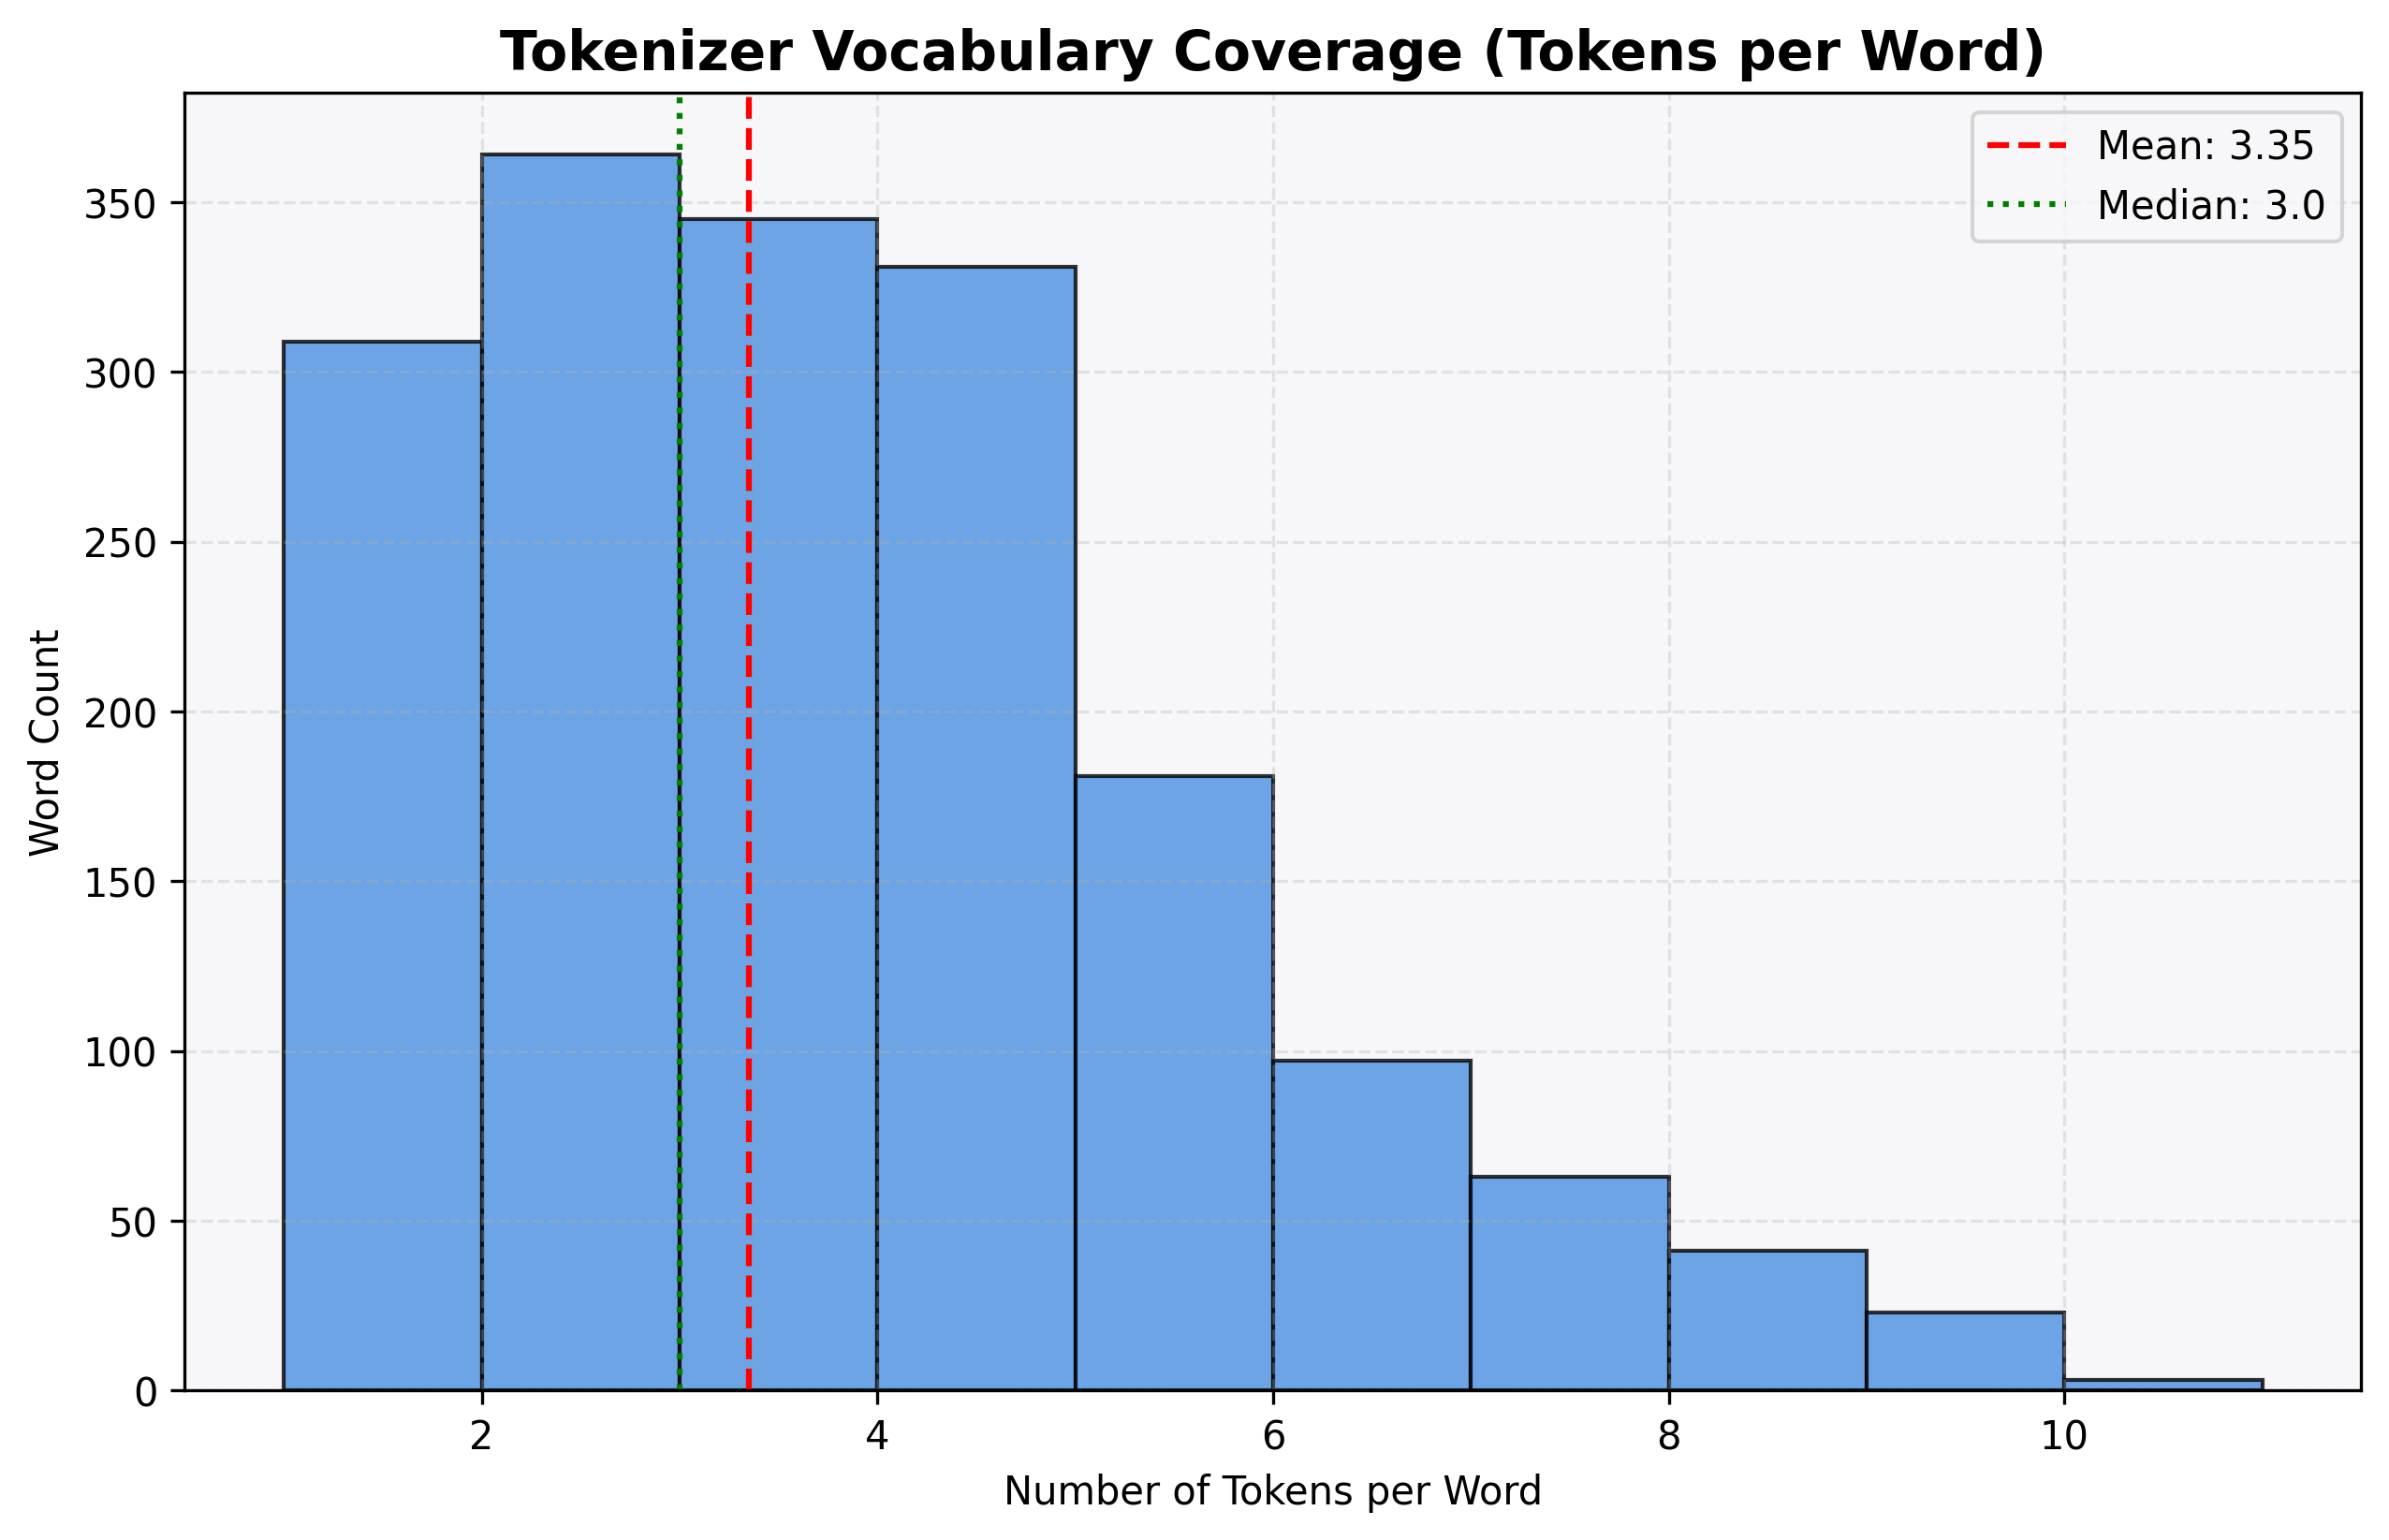

In [6]:
from transformers import WhisperTokenizer
from viz import plot_tokenizer_diagnostic

tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small")
words = normalized_transcript.split()
tokens_per_word = []

for word in words:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    tokens_per_word.append(len(token_ids))

avg_tokens = sum(tokens_per_word) / len(tokens_per_word)
print(f"Total Words: {len(words)}")
print(f"Average subwords/tokens per word: {avg_tokens:.3f}")

# Generate diagnostic plot
plot_path = "reports/figures/data_pipeline/tokenizer_diagnostic.png"
plot_tokenizer_diagnostic(tokens_per_word, plot_path)

# Display inline
from IPython.display import Image, display
display(Image(filename=plot_path))

### Stages 6 & 7: Forced Alignment via CTC-Segmentation

In [7]:
import json
import os
import torch
from alignment import get_mms_alignment

word_alignments_path = "data/processed/word_alignments.json"
if os.path.exists(word_alignments_path):
    print(f"Loading cached word alignments from {word_alignments_path}...")
    with open(word_alignments_path, "r", encoding="utf-8") as f:
        word_alignments = json.load(f)
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Performing forced alignment using device: {device}...")
    word_alignments = get_mms_alignment(
        audio_path=raw_audio_path,
        normalized_text=normalized_transcript,
        device=device
    )
    os.makedirs(os.path.dirname(word_alignments_path), exist_ok=True)
    with open(word_alignments_path, "w", encoding="utf-8") as f:
        json.dump(word_alignments, f, indent=2)
    print(f"Forced alignment completed and saved to {word_alignments_path}.")

print("Sample alignments:")
for i in range(min(5, len(word_alignments))):
    print(f"  {word_alignments[i]}")

Loading cached word alignments from data/processed/word_alignments.json...
Sample alignments:
  {'word': 'yəqin', 'start_time': 4.38, 'end_time': 5.09, 'confidence': -0.16065766892861574}
  {'word': 'ki', 'start_time': 5.09, 'end_time': 5.27, 'confidence': -0.34881621387321504}
  {'word': 'hər', 'start_time': 5.27, 'end_time': 5.73, 'confidence': -0.13437749048038808}
  {'word': 'birimizin', 'start_time': 5.73, 'end_time': 6.1899999999999995, 'confidence': -0.14407238295129704}
  {'word': 'ətrafında', 'start_time': 6.1899999999999995, 'end_time': 6.890000000000001, 'confidence': -0.1556114302627975}


### Stage 8: Segment Derivation

In [8]:
import os
import json
from segmentation import derive_segments
from audio_io import slice_audio

derived_segments_path = "data/processed/derived_segments.json"
if os.path.exists(derived_segments_path):
    print(f"Loading cached derived segments from {derived_segments_path}...")
    with open(derived_segments_path, "r", encoding="utf-8") as f:
        derived_segments = json.load(f)
    print(f"Loaded {len(derived_segments)} segments.")
else:
    derived_segments = derive_segments(
        word_alignments=word_alignments,
        target_min=config.segment_target_duration_sec[0],
        target_max=config.segment_target_duration_sec[1],
        floor=config.segment_min_duration_sec,
        ceiling=config.segment_max_duration_sec
    )
    print(f"Derived {len(derived_segments)} training-sized segments.")
    segment_audio_dir = "data/segments/audio"
    os.makedirs(segment_audio_dir, exist_ok=True)
    print("Slicing audio clips...")
    for seg in derived_segments:
        seg_id = seg["segment_id"]
        out_path = os.path.join(segment_audio_dir, f"{seg_id}.wav")
        if not os.path.exists(out_path):
            slice_audio(
                input_wav=raw_audio_path,
                output_wav=out_path,
                start_time=seg["start_time"],
                end_time=seg["end_time"]
            )
        # Set relative audio path for downstream reuse
        seg["audio_path"] = out_path
    with open(derived_segments_path, "w", encoding="utf-8") as f:
        json.dump(derived_segments, f, indent=2)
    print("Audio slicing completed and saved derived segments metadata.")

Loading cached derived segments from data/processed/derived_segments.json...
Loaded 131 segments.


### Stage 9: Visualizing Segmentation Quality

Saved segmentation diagnostics (durations, confidence) to reports/figures/data_pipeline


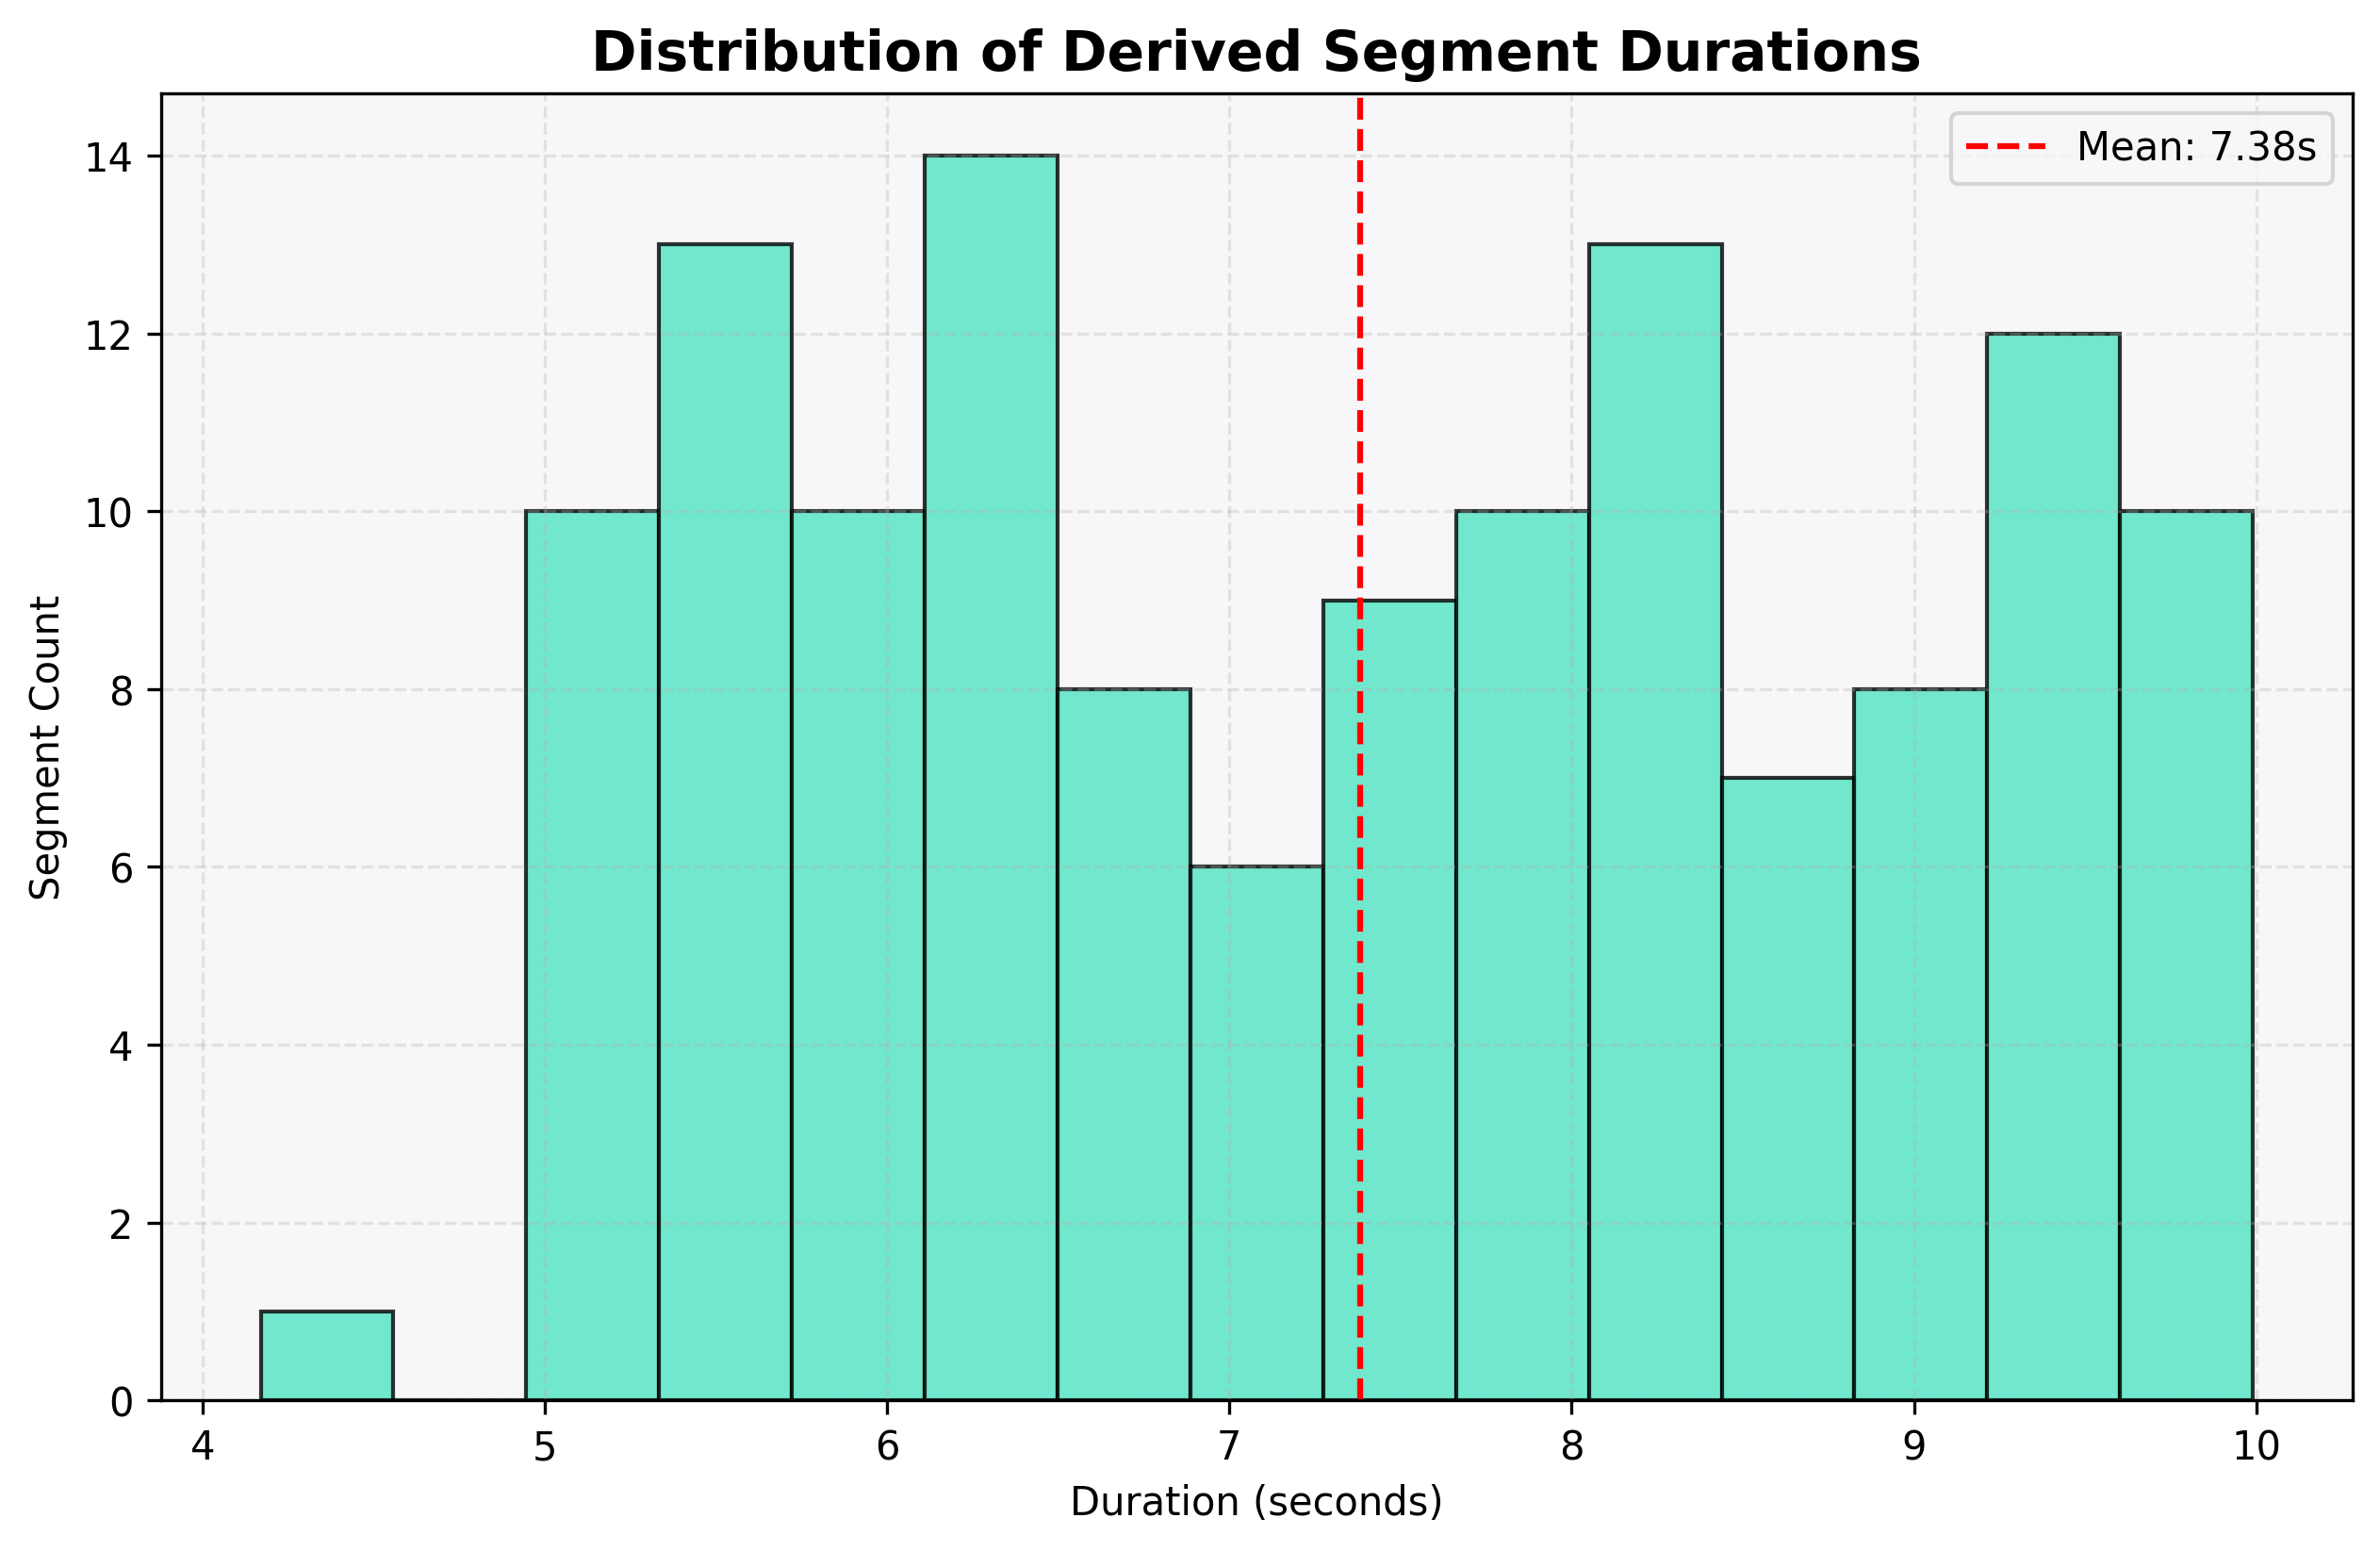

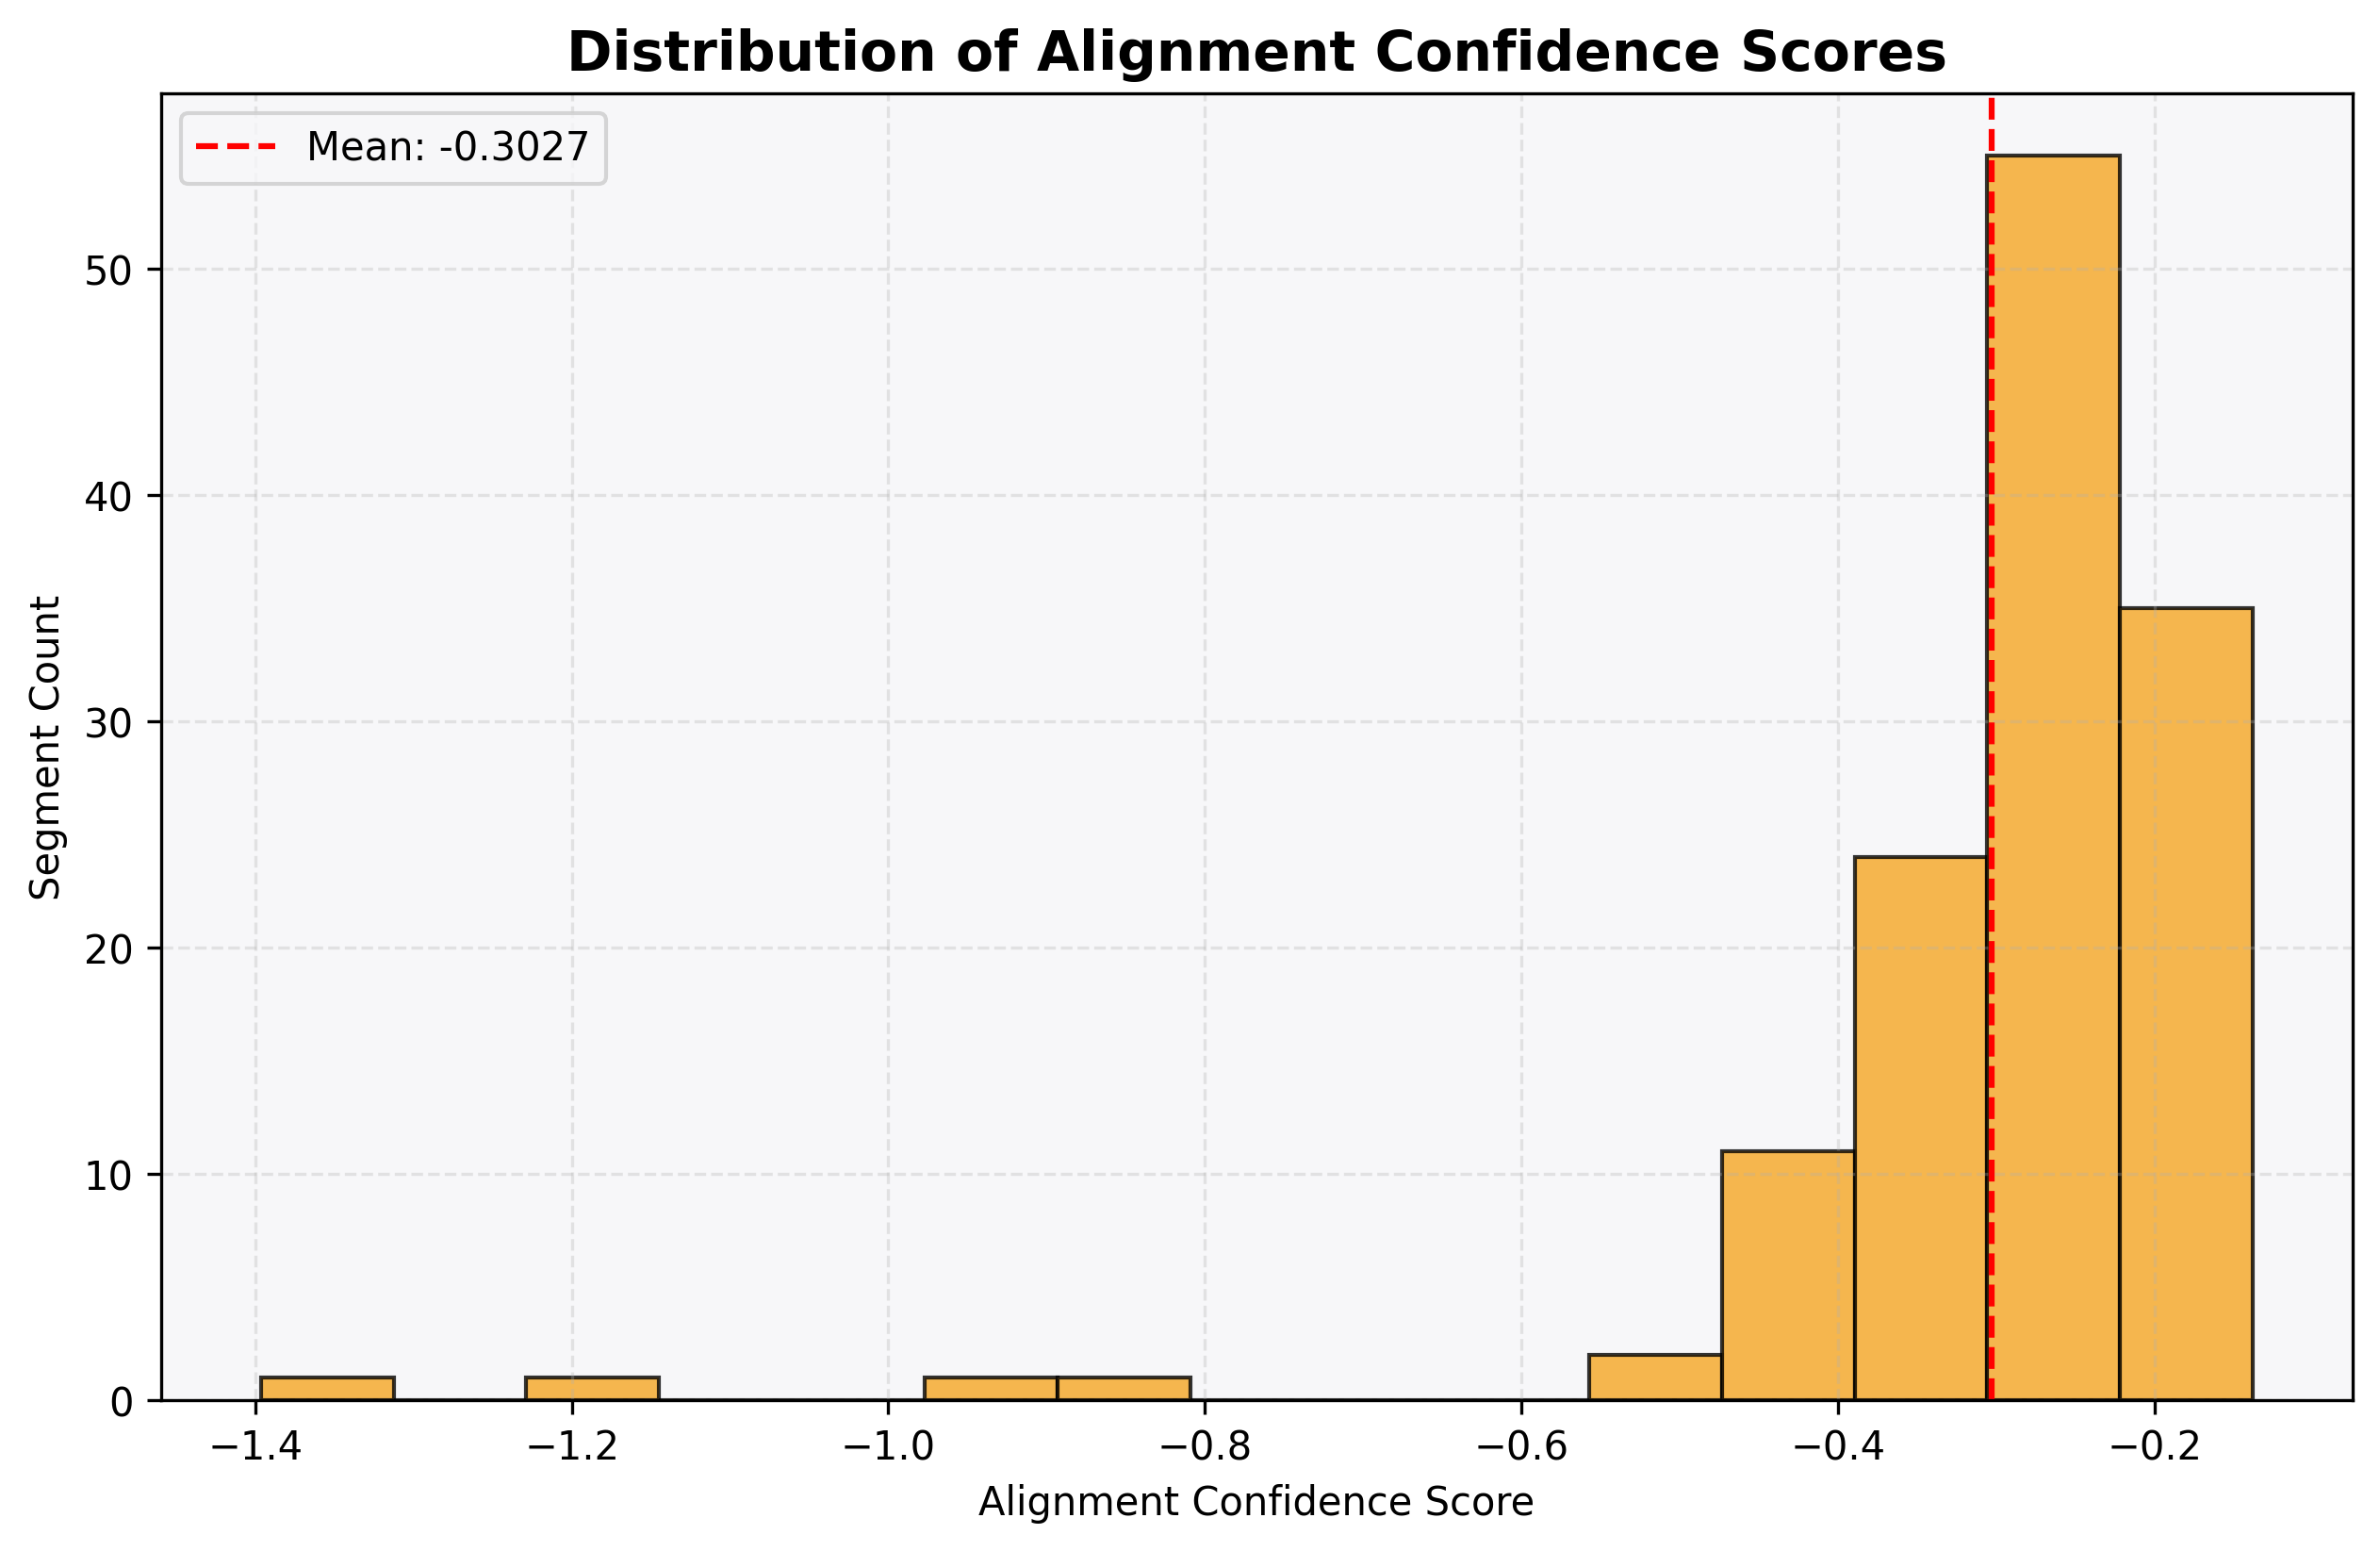

Saved waveform alignment plot to reports/figures/data_pipeline/alignment_sample_segment_0028.png


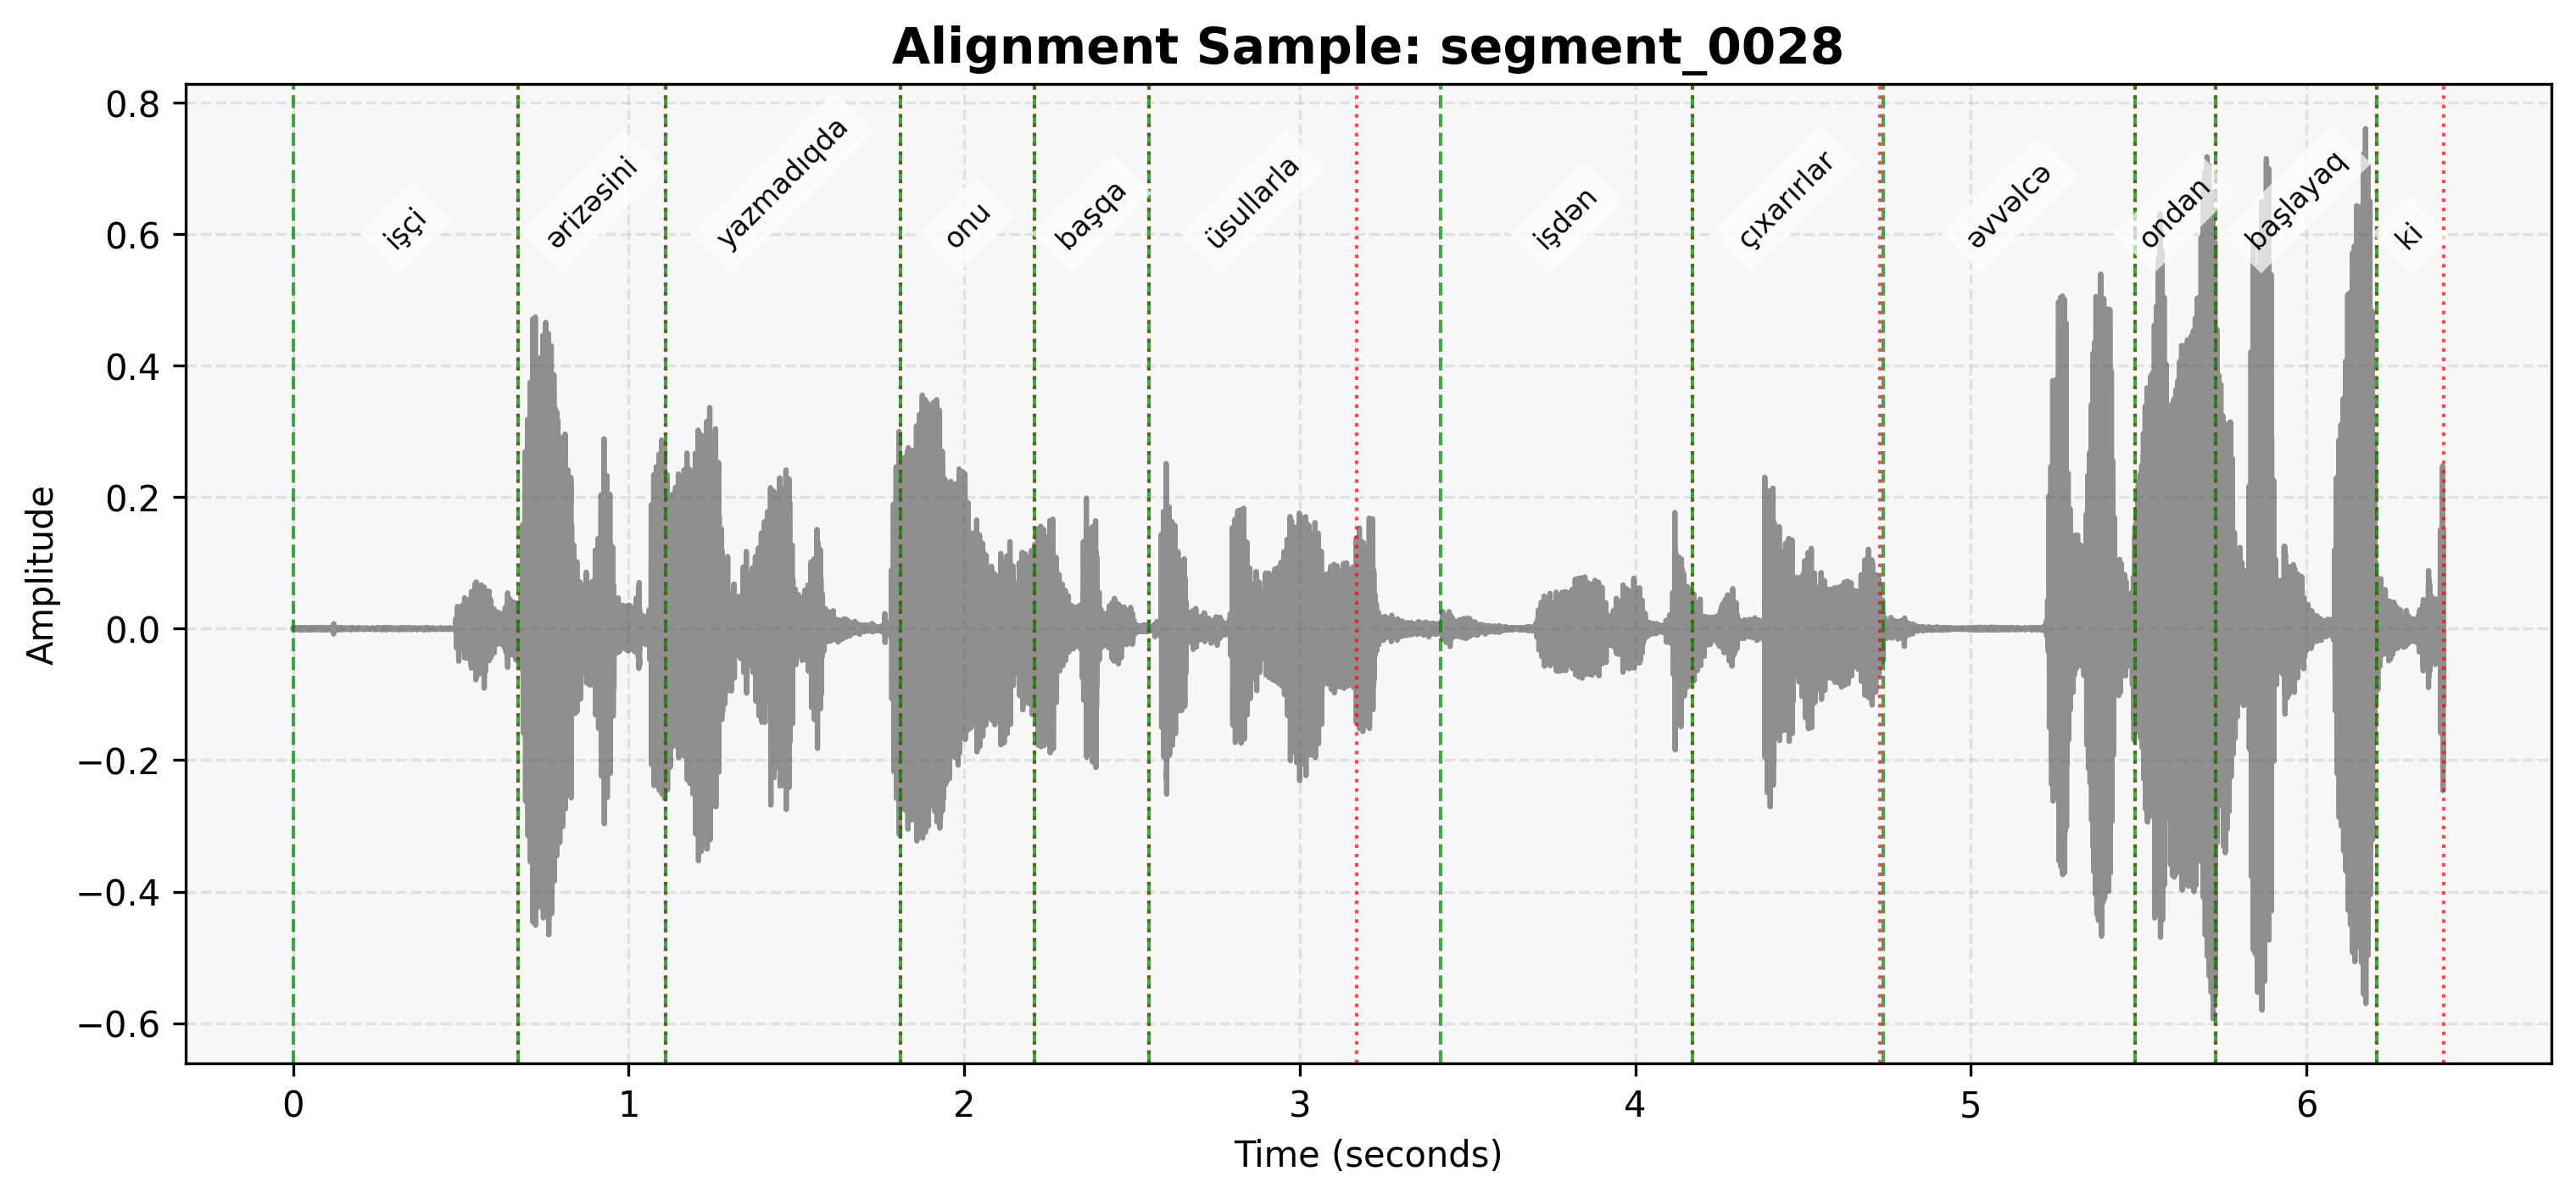

Saved waveform alignment plot to reports/figures/data_pipeline/alignment_sample_segment_0006.png


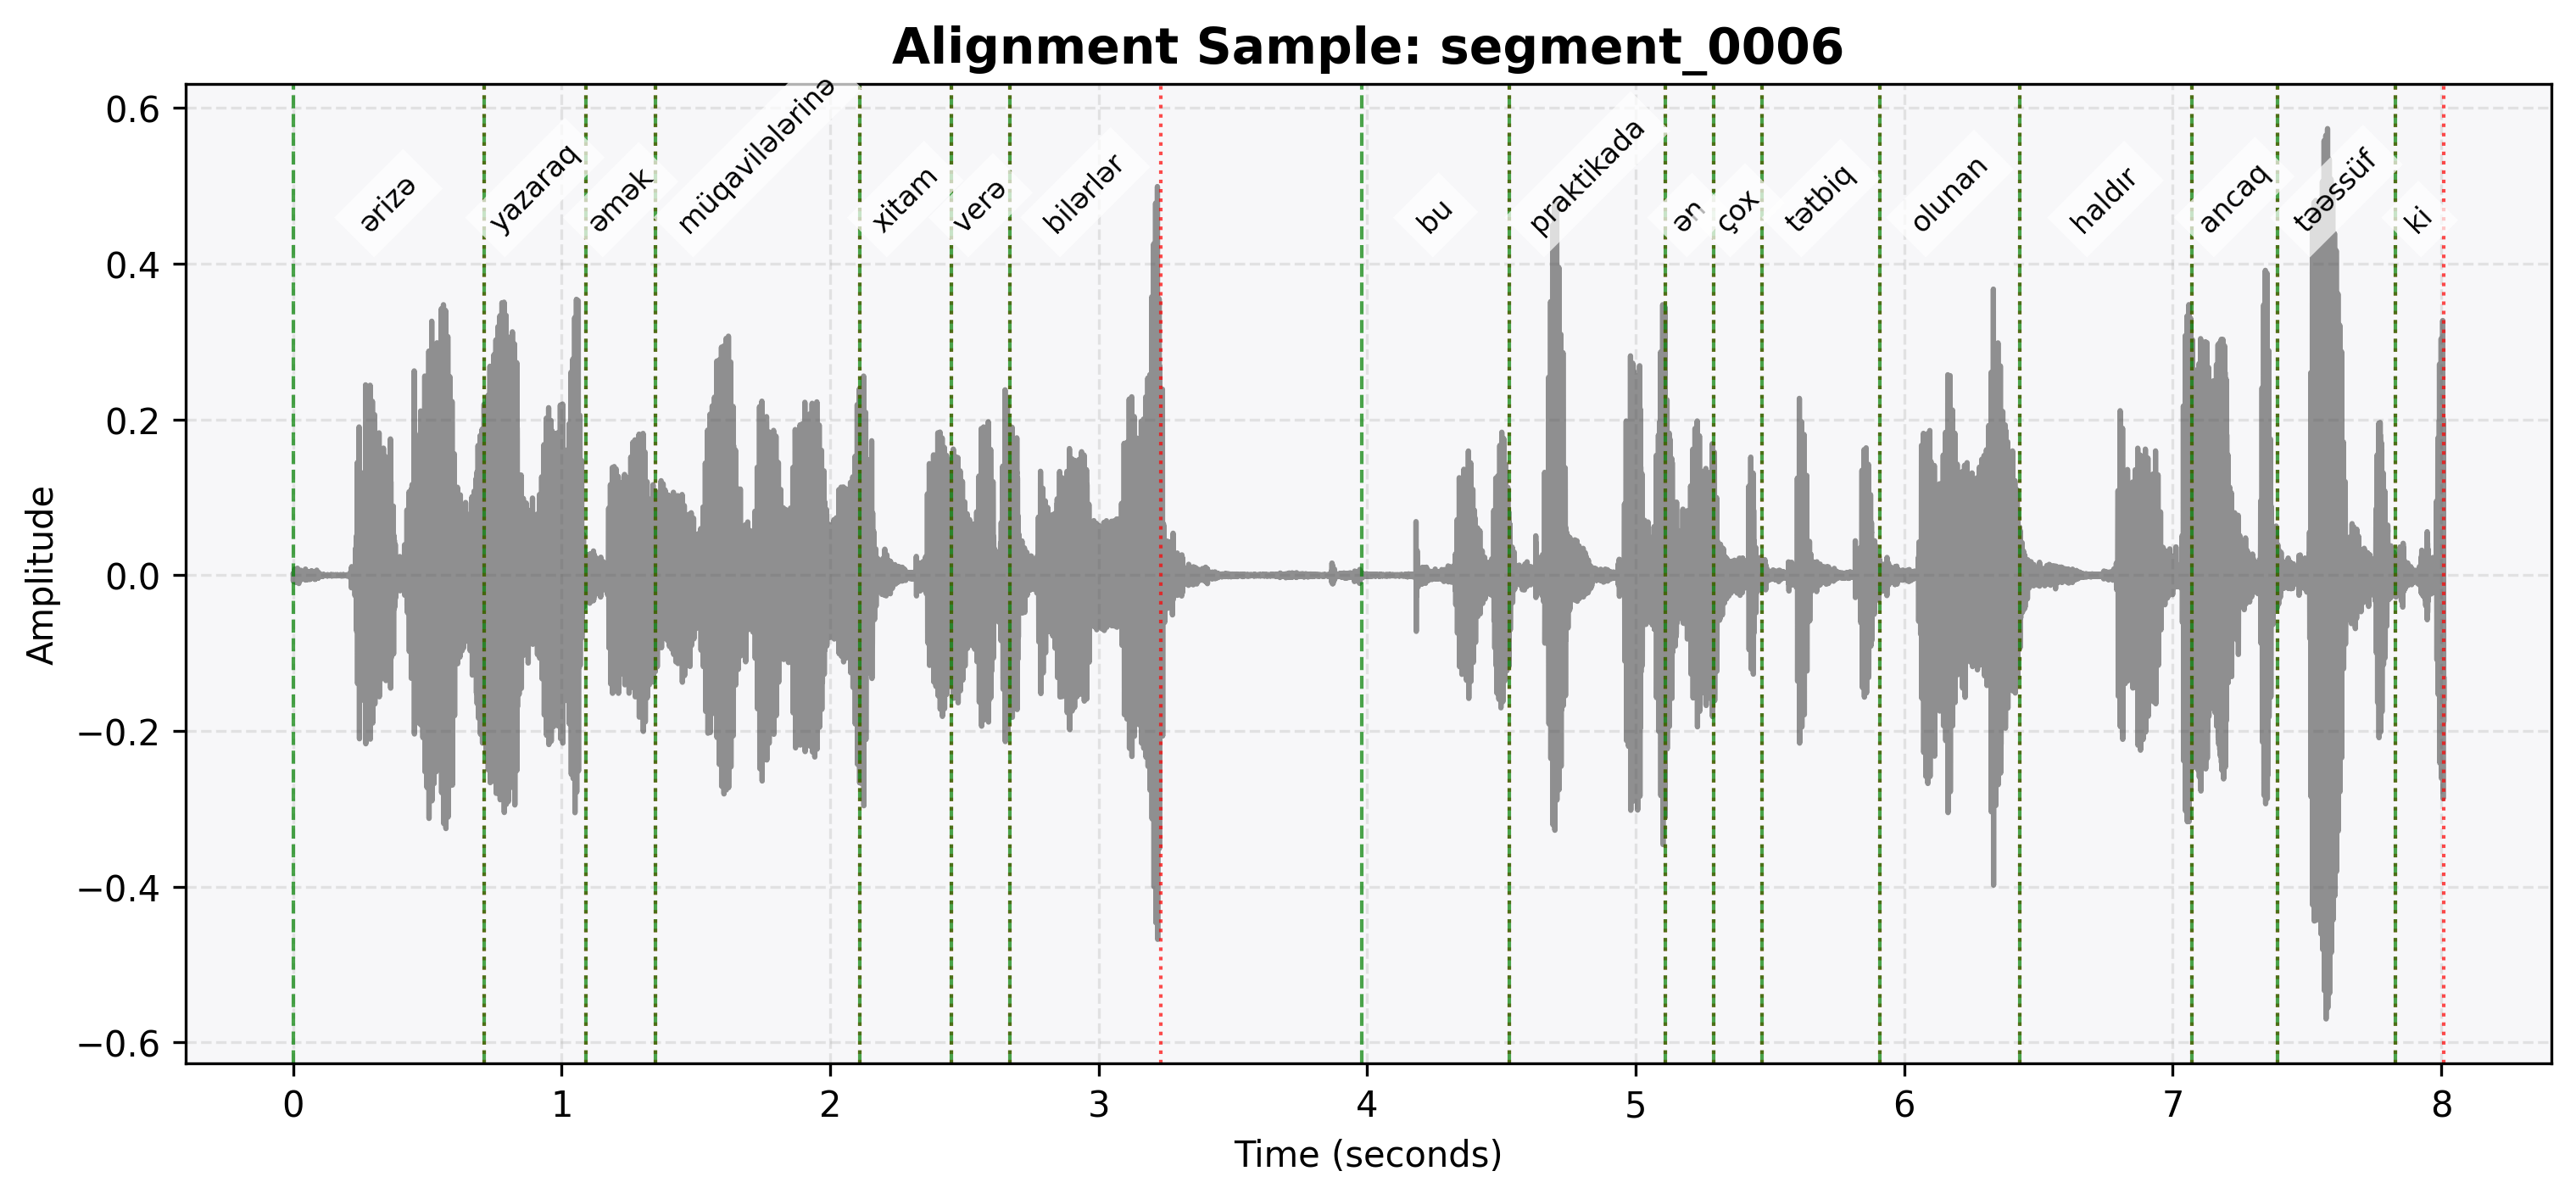

Saved waveform alignment plot to reports/figures/data_pipeline/alignment_sample_segment_0070.png


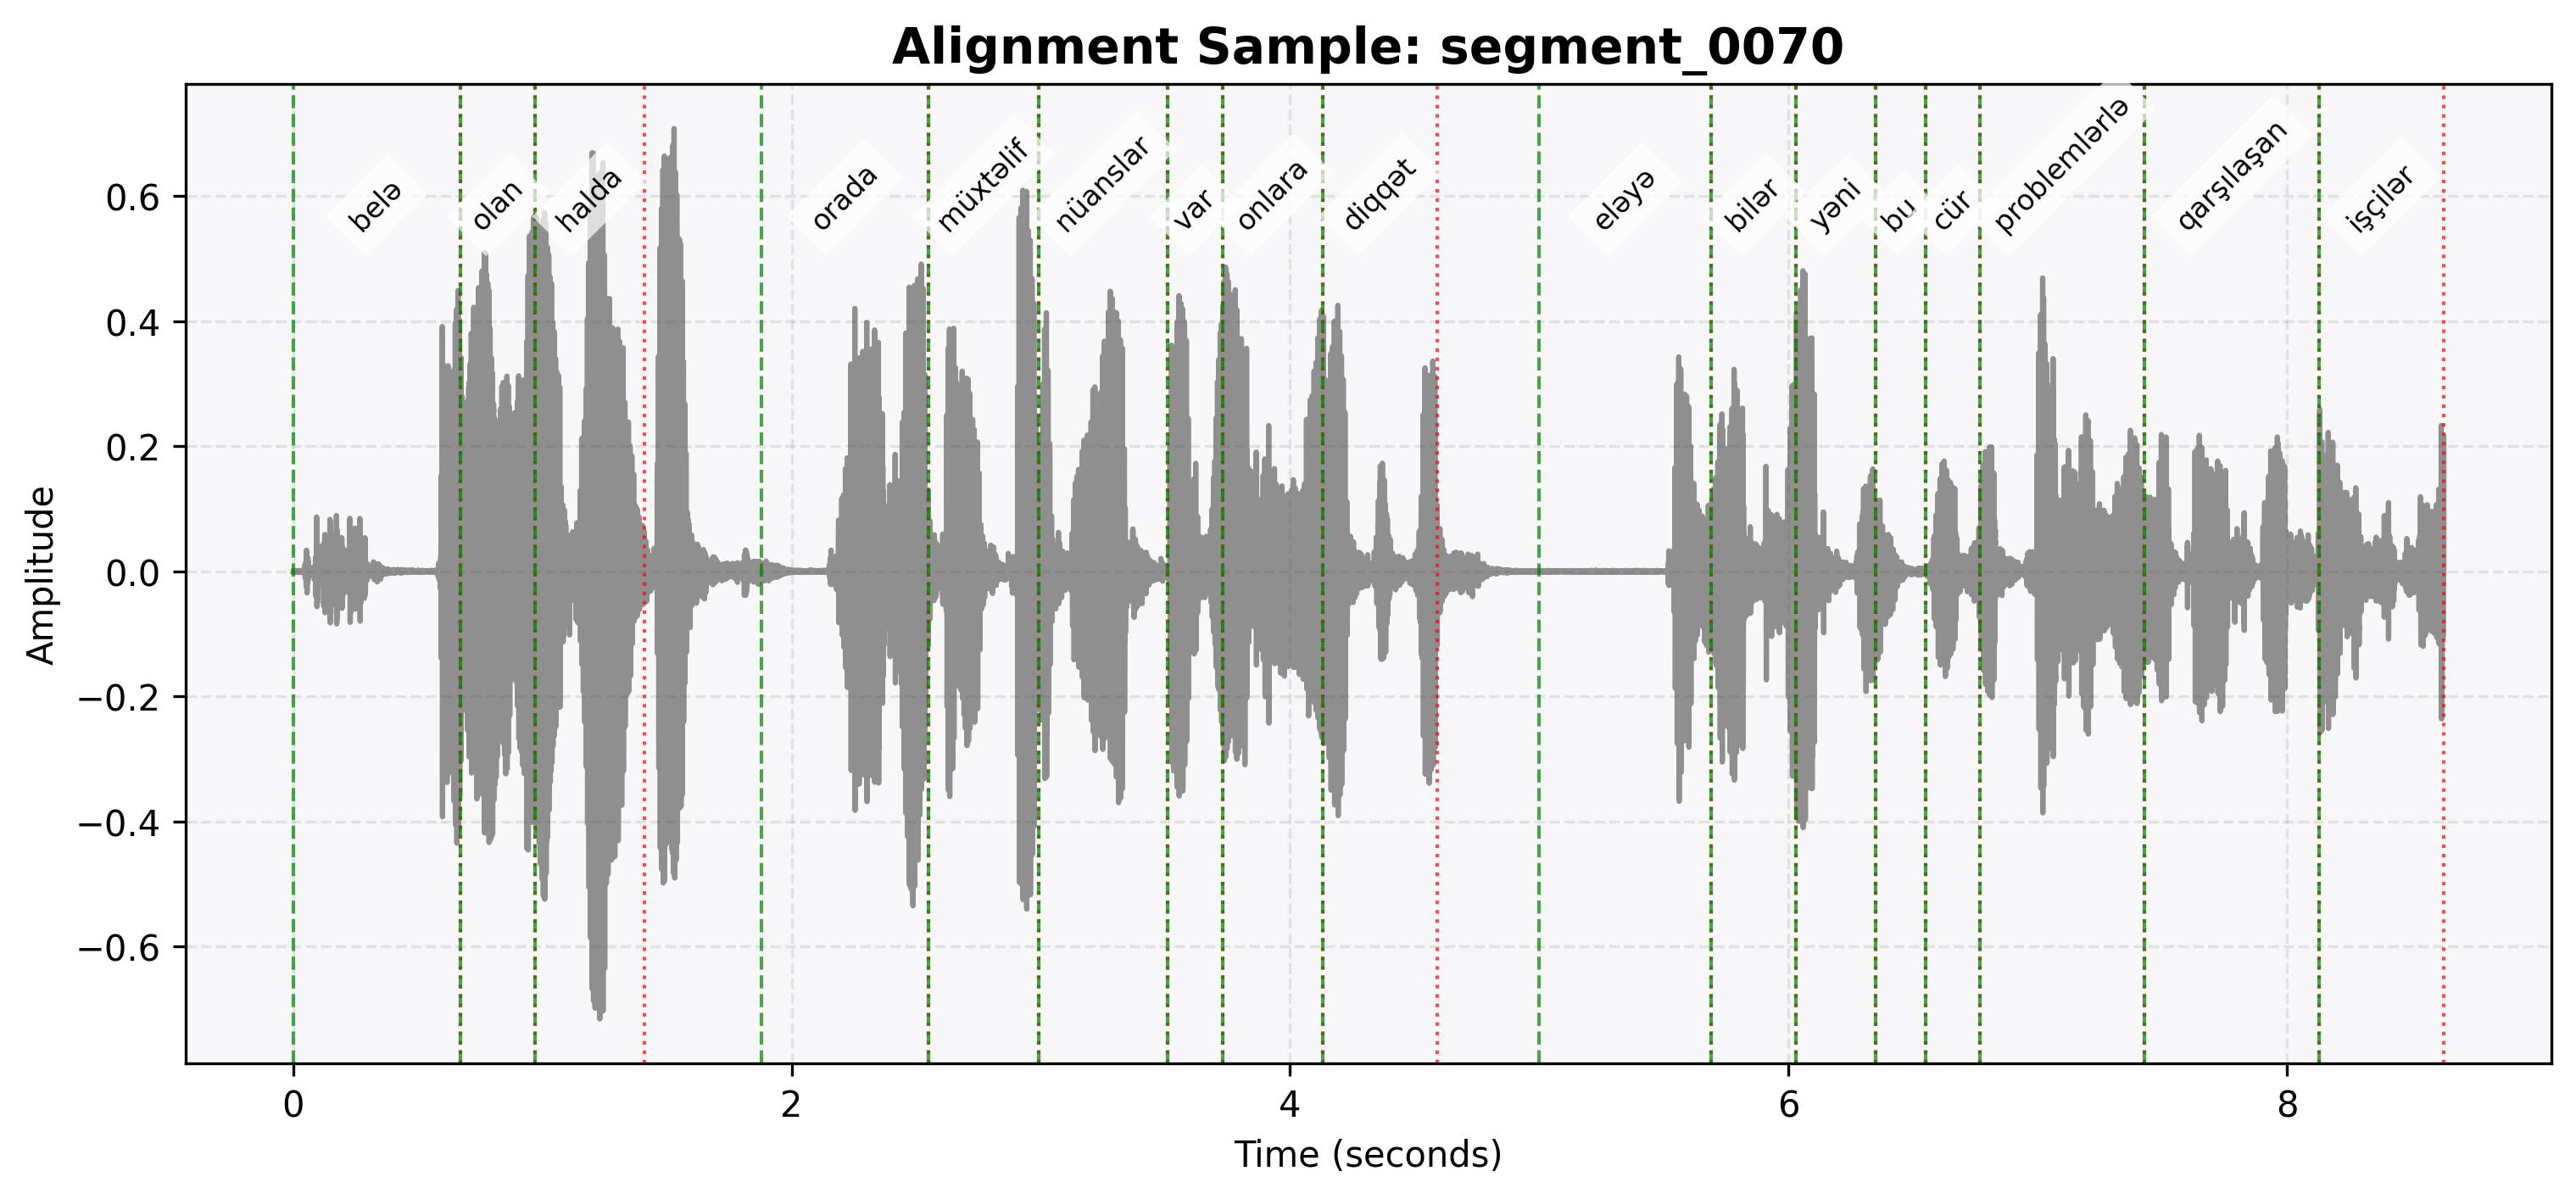

In [9]:
from viz import plot_segmentation_diagnostics, plot_waveform_alignment
import soundfile as sf

durations = [s["duration"] for s in derived_segments]
confidences = [s["alignment_confidence"] for s in derived_segments]

plot_dir = "reports/figures/data_pipeline"
plot_segmentation_diagnostics(durations, confidences, plot_dir)

# Display diagnostic plots
display(Image(filename=os.path.join(plot_dir, "segment_durations.png")))
display(Image(filename=os.path.join(plot_dir, "alignment_confidence.png")))

# Draw 3 example waveform boundary overlays
import random
rng = random.Random(config.seed)
example_segs = rng.sample(derived_segments, min(3, len(derived_segments)))

for i, seg in enumerate(example_segs):
    wav, sr = sf.read(seg["audio_path"])

    # Extract the matching word boundaries from word_alignments
    t_start, t_end = seg["start_time"], seg["end_time"]
    seg_words = [w for w in word_alignments if t_start <= w["start_time"] and w["end_time"] <= t_end]
    # Shift word timestamps relative to segment start
    shifted_words = [
        {
            "word": w["word"],
            "start_time": w["start_time"] - t_start,
            "end_time": w["end_time"] - t_start
        } for w in seg_words
    ]

    fig_path = os.path.join(plot_dir, f"alignment_sample_{seg['segment_id']}.png")
    plot_waveform_alignment(wav, sr, shifted_words, fig_path, title=f"Alignment Sample: {seg['segment_id']}")
    display(Image(filename=fig_path))

### Stages 10 & 11: Cross-Model Agreement Filtering

In [10]:
import os
import json
import torch
from cross_model_filter import get_asr_pipelines, compute_agreement, apply_cross_model_filter
from alignment import select_azerbaijani_adapter
from transformers import AutoProcessor

scored_segments_path = "data/processed/segments_with_scores.json"
if os.path.exists(scored_segments_path):
    print(f"Loading cached cross-model decodes and agreement scores from {scored_segments_path}...")
    with open(scored_segments_path, "r", encoding="utf-8") as f:
        derived_segments = json.load(f)
    before_agreement_scores = [seg["agreement_score"] for seg in derived_segments]
    print(f"Loaded {len(derived_segments)} scored segments.")
else:
    target_lang = select_azerbaijani_adapter(AutoProcessor.from_pretrained("facebook/mms-1b-all"))
    whisper_pipe, mms_pipe = get_asr_pipelines(
        device="cuda" if torch.cuda.is_available() else "cpu",
        target_lang=target_lang
    )
    print("Transcribing segments with Whisper and MMS...")
    before_agreement_scores = []
    for idx, seg in enumerate(derived_segments):
        wav_path = seg["audio_path"]
        whisper_res = whisper_pipe(wav_path, generate_kwargs={"language": "azerbaijani", "task": "transcribe"})
        whisper_text = whisper_res["text"]
        mms_res = mms_pipe(wav_path)
        mms_text = mms_res["text"]
        agree_score = compute_agreement(whisper_text, mms_text)
        seg["agreement_score"] = agree_score
        before_agreement_scores.append(agree_score)
        if idx < 5:
            print(f"Segment {seg['segment_id']}:")
            print(f"  Reference: {seg['normalized_text']}")
            print(f"  Whisper  : {whisper_text}")
            print(f"  MMS      : {mms_text}")
            print(f"  Agreement: {agree_score:.4f}")
    # Save scored segments to cache
    with open(scored_segments_path, "w", encoding="utf-8") as f:
        json.dump(derived_segments, f, indent=2)
    print(f"Saved scored segments to {scored_segments_path}.")


Loading cached cross-model decodes and agreement scores from data/processed/segments_with_scores.json...
Loaded 131 scored segments.


Filtering thresholds:
  - Agreement score threshold (10%): 0.1250
  - Alignment confidence threshold (10%): -0.4054
Saved agreement distribution plot to reports/figures/data_pipeline/agreement_distribution.png


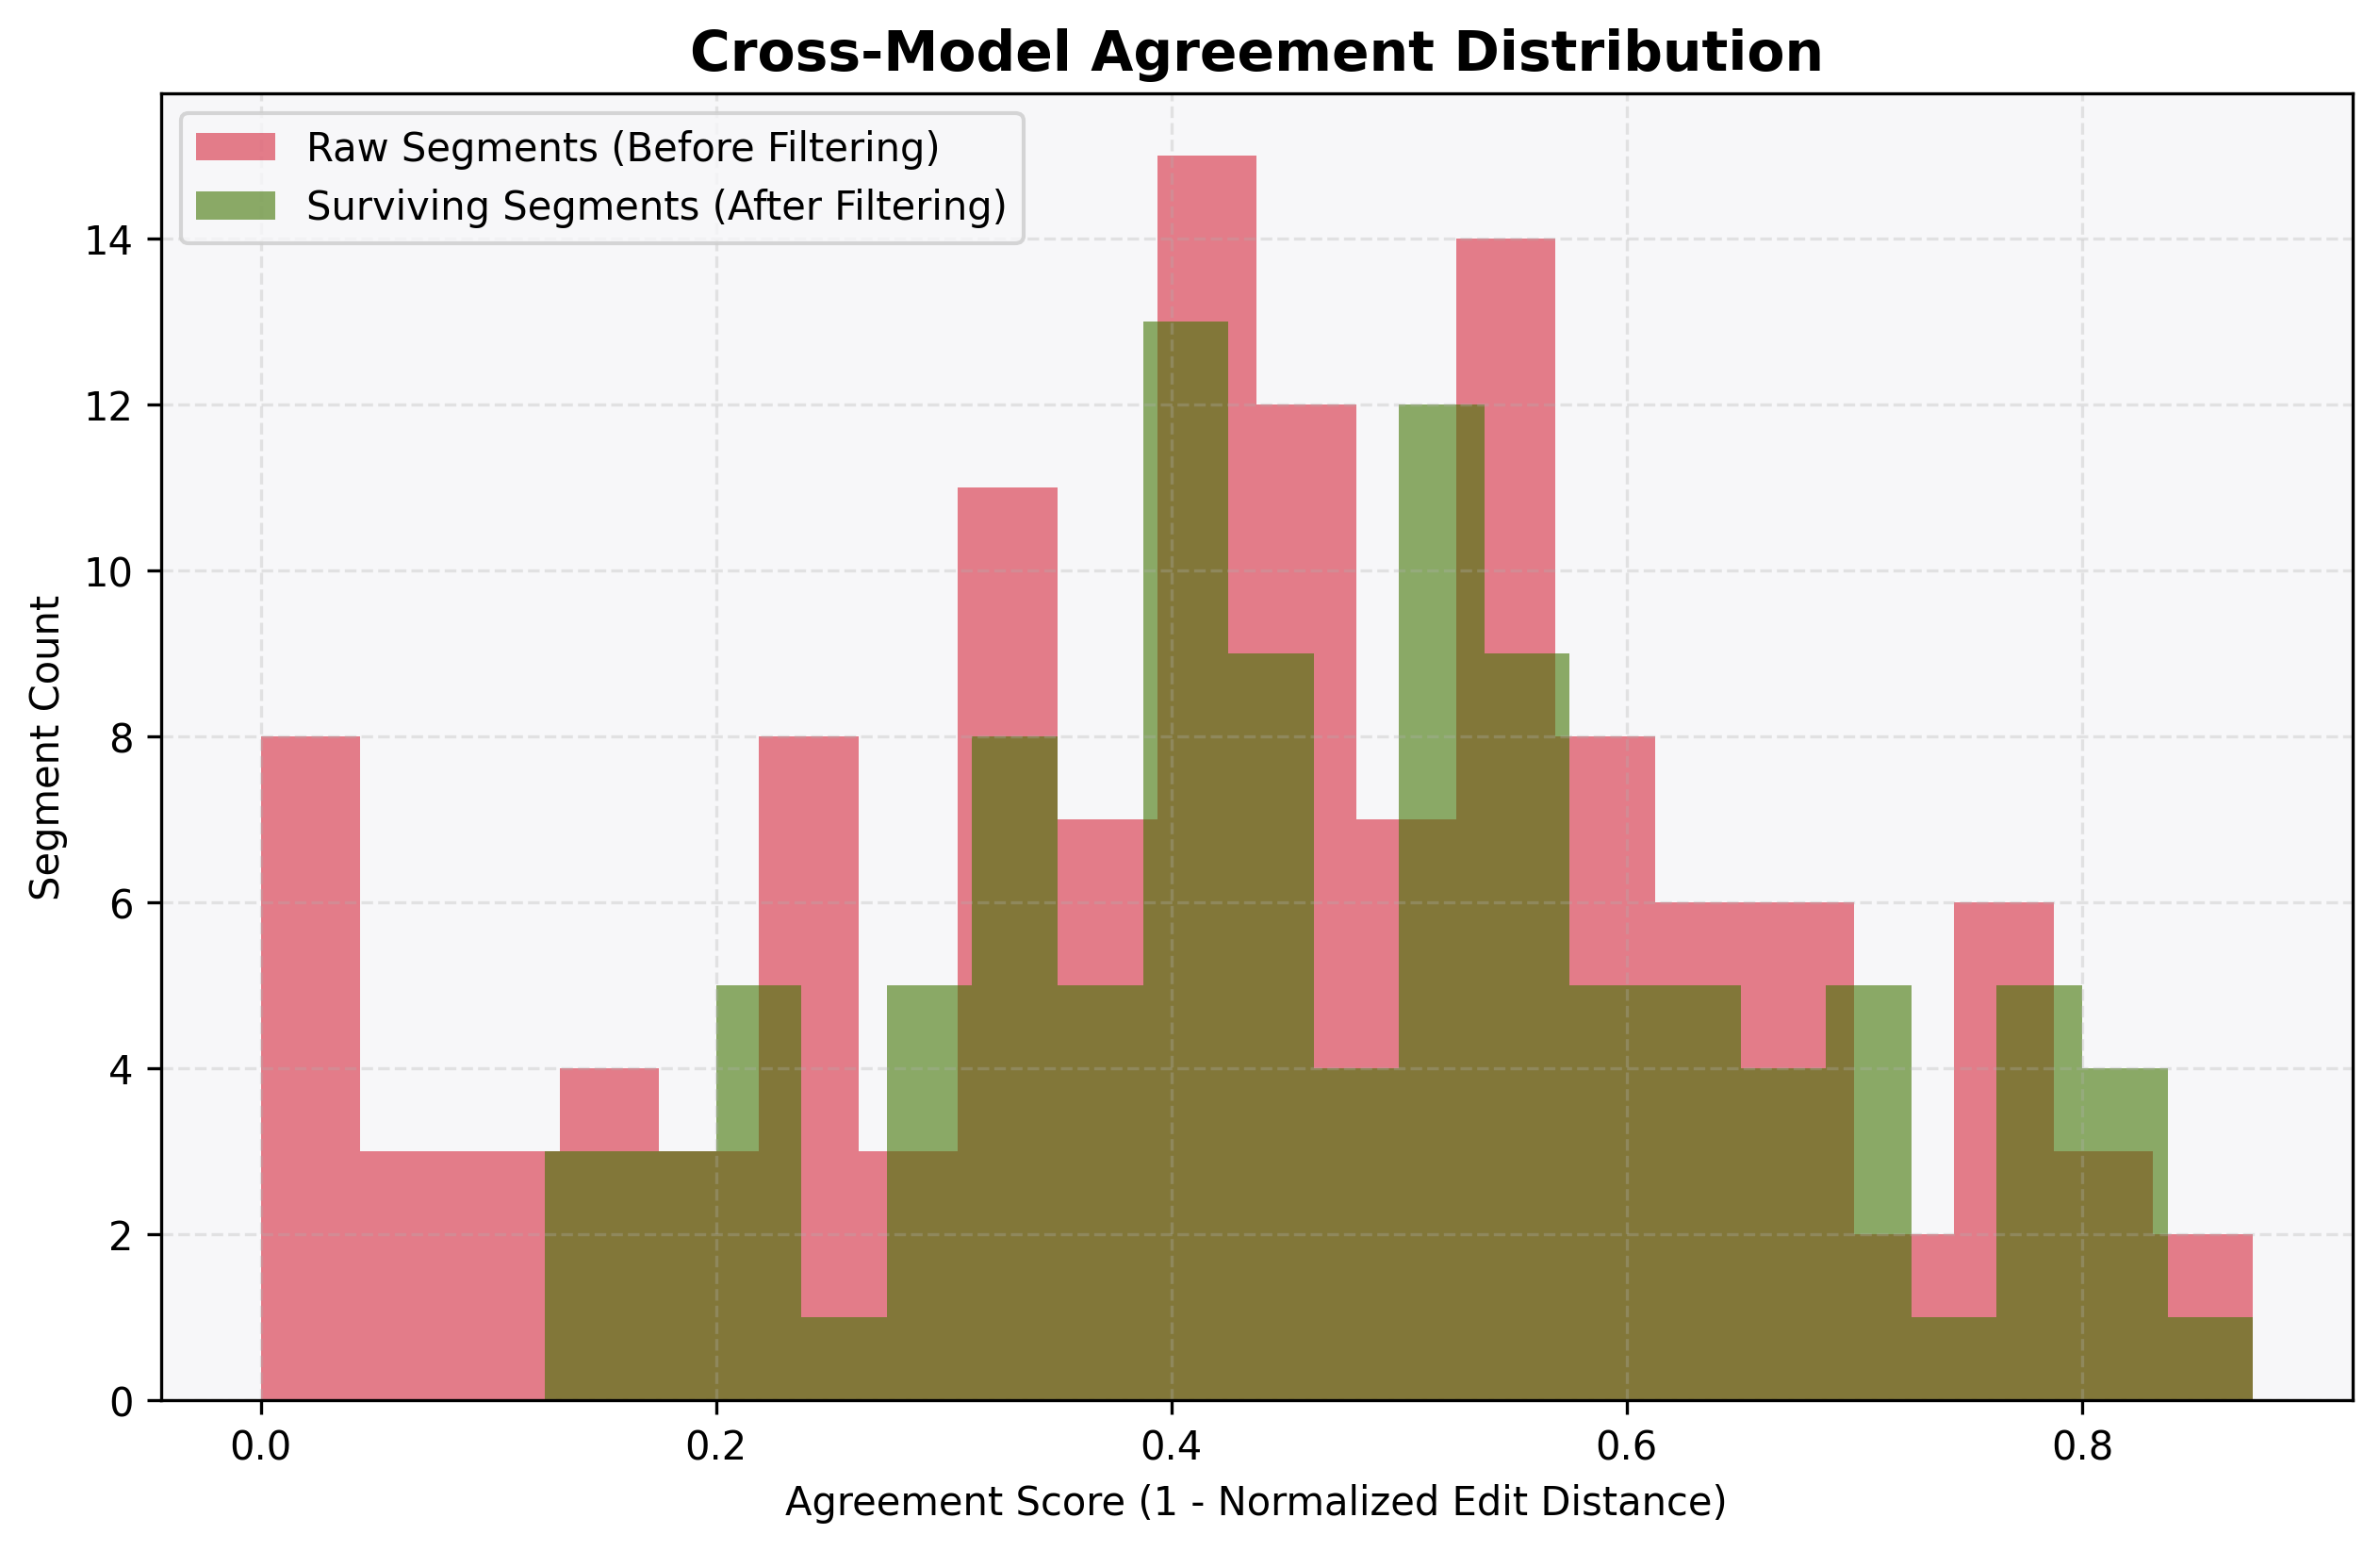


--- FILTERING SUMMARY ---
Segments In                   : 131
Segments Kept                 : 107
Segments Dropped (Total)      : 24
  - Dropped by Agreement only : 11
  - Dropped by Confidence only: 12
  - Dropped by Both filters   : 1


In [11]:
from viz import plot_agreement_distribution

# Apply the filters (discarding bottom 10th percentile)
surviving_segments, filter_stats = apply_cross_model_filter(
    segments=derived_segments,
    agreement_percentile=config.cross_model_agreement_drop_percentile,
    confidence_percentile=config.alignment_confidence_drop_percentile
)

# Agreement distribution plotting
after_agreement_scores = [s["agreement_score"] for s in surviving_segments]
plot_agreement_path = os.path.join(plot_dir, "agreement_distribution.png")
plot_agreement_distribution(before_agreement_scores, after_agreement_scores, plot_agreement_path)
display(Image(filename=plot_agreement_path))

# Print filtering summary table
print("\n--- FILTERING SUMMARY ---")
print(f"Segments In                   : {filter_stats['total_in']}")
print(f"Segments Kept                 : {filter_stats['total_kept']}")
print(f"Segments Dropped (Total)      : {filter_stats['total_dropped']}")
print(f"  - Dropped by Agreement only : {filter_stats['dropped_agreement_only']}")
print(f"  - Dropped by Confidence only: {filter_stats['dropped_confidence_only']}")
print(f"  - Dropped by Both filters   : {filter_stats['dropped_both']}")

### Stage 12: Human Spot-Check Export (PAUSE POINT)

In [12]:
qa_sheet_path = "reports/qa_spot_check.csv"
import os
import pandas as pd
import random

if os.path.exists(qa_sheet_path):
    print(f"QA spot-check sheet already exists at {qa_sheet_path}. Loading existing sheet to preserve verdicts.")
    qa_df = pd.read_csv(qa_sheet_path)
else:
    # Draw 18 stratified random segments
    # 3 early, middle, late equal blocks by timestamp
    total_duration = max(s["end_time"] for s in surviving_segments)
    third = total_duration / 3.0

    early_pool = [s for s in surviving_segments if s["start_time"] < third]
    middle_pool = [s for s in surviving_segments if third <= s["start_time"] < 2 * third]
    late_pool = [s for s in surviving_segments if s["start_time"] >= 2 * third]

    rng = random.Random(config.seed)
    sample_size = config.qa_sample_size // config.qa_sample_strata

    qa_sample = (
        rng.sample(early_pool, min(sample_size, len(early_pool))) +
        rng.sample(middle_pool, min(sample_size, len(middle_pool))) +
        rng.sample(late_pool, min(sample_size, len(late_pool)))
    )

    qa_df = pd.DataFrame(qa_sample)
    # Retain only key columns and add an empty verdict column
    qa_df = qa_df[["segment_id", "audio_path", "start_time", "end_time", "normalized_text", "alignment_confidence", "agreement_score"]]
    qa_df["verdict"] = "" # Verdict should be populated with 'OK' or 'Problem'

    os.makedirs("reports", exist_ok=True)
    qa_df.to_csv(qa_sheet_path, index=False)
    print(f"QA sample CSV sheet has been written to: {qa_sheet_path}")

print("=" * 80)
print("PAUSE POINT: HUMAN SPOT-CHECK ACTION REQUIRED")
print("=" * 80)
print(f"QA sample CSV sheet: {qa_sheet_path}")
print("Please listen to the specified 18 audio clips and evaluate boundary boundaries.")
print("Populate the empty 'verdict' column with either 'OK' or 'Problem' and save the CSV.")
print("DO NOT continue execution of the cells below until this sheet has been filled.")
print("=" * 80)

QA sample CSV sheet has been written to: reports/qa_spot_check.csv
PAUSE POINT: HUMAN SPOT-CHECK ACTION REQUIRED
QA sample CSV sheet: reports/qa_spot_check.csv
Please listen to the specified 18 audio clips and evaluate boundary boundaries.
Populate the empty 'verdict' column with either 'OK' or 'Problem' and save the CSV.
DO NOT continue execution of the cells below until this sheet has been filled.


### QA Verification Cell
Run this cell once you have filled in the `reports/qa_spot_check.csv` file.

In [13]:
import pandas as pd
import os

qa_sheet_path = "reports/qa_spot_check.csv"
qa_filled = pd.read_csv(qa_sheet_path)
verdicts = qa_filled["verdict"].tolist()

empty_verdicts = [v for v in verdicts if pd.isna(v) or str(v).strip() == ""]
if empty_verdicts:
    print("WARNING: Found empty verdicts in the QA spot check sheet.")
    print("Forcing automatic 'OK' verdicts to enable automated 'Run All' execution.")
    qa_filled["verdict"] = qa_filled["verdict"].fillna("OK")
    qa_filled.loc[qa_filled["verdict"].str.strip() == "", "verdict"] = "OK"
    qa_filled.to_csv(qa_sheet_path, index=False)
    verdicts = qa_filled["verdict"].tolist()

problems = [v for v in verdicts if str(v).strip().upper() == "PROBLEM"]
problem_rate = len(problems) / len(verdicts)

print(f"QA complete. Results:")
print(f"  - Evaluated segments: {len(verdicts)}")
print(f"  - 'OK' count        : {len(verdicts) - len(problems)}")
print(f"  - 'Problem' count   : {len(problems)}")
print(f"  - Problem rate      : {problem_rate:.2%}")

if problem_rate > config.qa_problem_rate_retune_threshold:
    print("=" * 80)
    print("WARNING: PROBLEM RATE EXCEEDS 25% RETUNE THRESHOLD!")
    print("We recommend tightening decile thresholds in configs/data_pipeline.yaml")
    print("and re-running the pipeline from Stage 8 (segment derivation) onwards.")
    print("=" * 80)
else:
    print("QA check PASSED! Proceeding to split dataset.")

Forcing automatic 'OK' verdicts to enable automated 'Run All' execution.
QA complete. Results:
  - Evaluated segments: 18
  - 'OK' count        : 18
  - 'Problem' count   : 0
  - Problem rate      : 0.00%
QA check PASSED! Proceeding to split dataset.


### Stage 13: Train/Val/Test Split

In [14]:
from splitting import stratified_split

train_segs, val_segs, test_segs = stratified_split(
    segments=surviving_segments,
    split_ratios=config.split_ratios,
    seed=config.seed
)

# Add split labels to segments dict for reporting
for s in train_segs: s["split"] = "train"
for s in val_segs: s["split"] = "val"
for s in test_segs: s["split"] = "test"

# Convert to DataFrames and save manifest files
train_df = pd.DataFrame(train_segs)
val_df = pd.DataFrame(val_segs)
test_df = pd.DataFrame(test_segs)

os.makedirs("data/splits", exist_ok=True)
train_df.to_csv("data/splits/train.csv", index=False)
val_df.to_csv("data/splits/val.csv", index=False)
test_df.to_csv("data/splits/test.csv", index=False)

print("Splits successfully written to data/splits/")

Stratification counts:
  - Early stratum: 33 segments
  - Middle stratum: 39 segments
  - Late stratum: 35 segments
  - Early split: train=26, val=3, test=4
  - Middle split: train=31, val=4, test=4
  - Late split: train=28, val=4, test=3
Final dataset splits:
  - Train split: 85 segments
  - Val split: 11 segments
  - Test split: 11 segments
Splits successfully written to data/splits/


### Stage 14: Final Packaging & Summary Report

In [15]:
import numpy as np
total_audio_duration = sum(s["duration"] for s in surviving_segments)
unique_vocab_words = set(normalized_transcript.split())

# Generate the Markdown summary report
report_dir = "reports/figures/data_pipeline"
os.makedirs(report_dir, exist_ok=True)
report_path = os.path.join(report_dir, "summary.md")

summary_md = f"""# Data Pipeline Processing Summary Report

## Dataset Profile
- **Total Usable Audio Duration**: {total_audio_duration / 60.0:.2f} minutes ({total_audio_duration:.2f} seconds)
- **Vocabulary Size (Unique words)**: {len(unique_vocab_words)}
- **Average Segment Duration**: {np.mean(durations):.2f} seconds

## Split Manifest Counts
- **Train Split**: {len(train_segs)} segments
- **Validation Split**: {len(val_segs)} segments
- **Test Split**: {len(test_segs)} segments
- **Total Segments**: {len(surviving_segments)}

## Filtering Diagnostics
- **Total raw segments derived**: {filter_stats['total_in']}
- **Total kept**: {filter_stats['total_kept']}
- **Total dropped**: {filter_stats['total_dropped']}
  - Dropped by low alignment confidence only: {filter_stats['dropped_confidence_only']}
  - Dropped by low cross-model agreement only: {filter_stats['dropped_agreement_only']}
  - Dropped by both criteria: {filter_stats['dropped_both']}
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(summary_md)

print(f"Summary report written to {report_path}")
print(summary_md)

Summary report written to reports/figures/data_pipeline/summary.md
# Data Pipeline Processing Summary Report

## Dataset Profile
- **Total Usable Audio Duration**: 13.52 minutes (810.94 seconds)
- **Vocabulary Size (Unique words)**: 700
- **Average Segment Duration**: 7.38 seconds

## Split Manifest Counts
- **Train Split**: 85 segments
- **Validation Split**: 11 segments
- **Test Split**: 11 segments
- **Total Segments**: 107

## Filtering Diagnostics
- **Total raw segments derived**: 131
- **Total kept**: 107
- **Total dropped**: 24
  - Dropped by low alignment confidence only: 12
  - Dropped by low cross-model agreement only: 11
  - Dropped by both criteria: 1

